# Väder och luftkvalitet. Analys med dataset World Weather Repository

## Dataset
Detta dataset innehåller väder samt luftkvalitetsmätningar från huvudstäder världen över. I nuvarande form har det över 40 mätvärden så som temperatur, vind, lufttryck, luftfuktighet och luftkvalitet.
Luftkvalitet mäts i CO, O3, NO2, SO2, PM2.5, PM10, GB DEFRA Index samt US EPA Index. 
Datasetet innehåller 142 093 rader med mätstart 29-08-2023 och är tänkt att användas till klimat analyser, väderindikationer, miljöpåverkan turismplanering samt geografiska mönster.

Tre frågor som jag initial vill visualisera är

Samband mellan temperatur och PM2.5?
Hur varierar EPA-index mellan länder?
Påverkar molninghet UV index?

In [5]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Inläsning och inspektion

Läser in datan och gör en inital inspektion av form, datatyper i kolumnerna, kolumner som saknar värden samt kontroll av dubletter.

In [6]:
# inital data exploration

df = pd.read_csv("dataset/GlobalWeatherRepository.csv")
df.shape
df.info()
#df.columns.tolist()
# No data fields are missing values
print(df.isnull().sum())
print(f"Total missing: {df.isnull().sum().sum()}")
# No duplicates in data
print(f"Duplicates:  {df.duplicated().sum()}")

# last_updated is str, needs update to date

# Check describe

df.describe()

# Data contains extreme values that are most likly incorrect (temperature_celsius = 79.300000,  gust_kph = 2970.400000)

<class 'pandas.DataFrame'>
RangeIndex: 142093 entries, 0 to 142092
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       142093 non-null  str    
 1   location_name                 142093 non-null  str    
 2   latitude                      142093 non-null  float64
 3   longitude                     142093 non-null  float64
 4   timezone                      142093 non-null  str    
 5   last_updated_epoch            142093 non-null  int64  
 6   last_updated                  142093 non-null  str    
 7   temperature_celsius           142093 non-null  float64
 8   temperature_fahrenheit        142093 non-null  float64
 9   condition_text                142093 non-null  str    
 10  wind_mph                      142093 non-null  float64
 11  wind_kph                      142093 non-null  float64
 12  wind_degree                   142093 non-null  int64  


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,142093.000000,142093.000000,1.420930e+05,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,...,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000,142093.000000
mean,19.217823,21.935780,1.747472e+09,21.239673,70.233200,7.985642,12.855347,168.902655,1014.031008,29.943734,...,18.189434,451.220042,57.649808,14.833681,10.142997,23.880885,47.809385,1.687845,2.579409,49.724019
std,24.412454,65.782841,1.825321e+07,9.641270,17.354162,7.128596,11.469055,103.665704,10.193741,0.300965,...,13.691935,745.241895,30.458190,23.372941,34.878387,36.317171,147.518483,0.934258,2.424634,35.103958
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731747e+09,15.500000,59.900000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,196.236000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747472e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,288.600000,55.000000,5.735000,2.405000,13.950000,19.610000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.763192e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,453.250000,73.000000,17.050000,8.140000,27.380000,40.885000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.779086e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


## Datatvätt

Analysen av datan visar några problem samt överflödig data som behöver hanters för att kunna använda datasetet korrekt. 

### Imperial units 
    - Behövs inte, dessa ska filtereras bort i datatvätt

### Platshållar värden
    - Datasetet innehåller inga noll värden men har värden som är platshållare. 
    - Tex air_quality_Carbon_Monoxide och air_quality_Sulphur_dioxide med värde - 9999

### Omöjliga och orimliga värden
    - Några värden är fysiskt omöjliga och är troligen felmätningar eller felaktigt angiven data
    - temperature_celsius med max värde 79.3. Högsta uppmätta 56,7 den 10/07 1913 i death valley
    - wind_kph med max värde 1841.2 km/h. Högsta uppmätta är 480 km/h ± 32 km/h 3/05 1999 i en F5 tornado vid Oklahoma City. Ljudets hastighet = ca 1224 km/h
    - pressure_mb, lufttryck i mbar. Högsta uppmätta någonsin är 1085,6 19/12 2001 i Tosontsengel–Khövsgöl-provinsen, Mongoliet.
    - 947 pressure_mb, min är rimligt, lägsta uppmätta är 870 12/10 1979. 
    - PM2.5 samt PM10. Orimliga maxvärden på 1614 respektive 6037

### Datum har datatyp string
    - last_updated har datatyp string, behöver konverteras till datetime
    - last_updated_epoch. Unix timestamp 

### CO och SO2 får datatyp object när platshållarvärden omvandlas till NaN
    - Omvandla Co och SO2 till numerisk datatyp i datatvätts funktion

### Vi bygger en datatvätt funktion som rensar bort platshållare, onödig och omöjlig data. Först kontrollerar vi dock hur många datafält vi tappar på att rensa bort denna data


In [7]:
# Remove extreme values and check how much data is lost. Proceed with clean if dataloss is deemed acceptable

print(f"Initial längd: {len(df)}")

initial_length = len(df)

hide_extremes = (
    df["temperature_celsius"].between(-89.2, 56.7) &
    (df["wind_kph"] < 1235) &
    (df["pressure_mb"].between(870, 1084)) &
    (df["air_quality_PM2.5"] < 500) &
    (df["air_quality_PM10"] < 2000)
)

print("Rader som filtreras bort:", (~hide_extremes).sum())
print("Rader efter:", hide_extremes.sum())
percent_removed = "{:.2f}".format((~hide_extremes).sum()/initial_length * 100)
print(f"Procent rader av datan som filterats: {percent_removed}%")

#Deemed acceptable

placeholder_to_NaN = df.replace(-9999, pd.NA)
print("-------------------------------------")
print(f"Antal null värden per kolumn \n{placeholder_to_NaN.isna().sum()}")
print("-------------------------------------")
print(f"Totalt antal null värden: {placeholder_to_NaN.isna().sum().sum()}")


Initial längd: 142093
Rader som filtreras bort: 246
Rader efter: 141847
Procent rader av datan som filterats: 0.17%
-------------------------------------
Antal null värden per kolumn 
country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0


### 0.17% av datan tas bort vid en filtrering av extremvärden. En dataförlust som bedöms acceptabel
### Två fält ersätts av NAN när vi ersätter platshållarvärden. Dessa kan fortsätta leva som NaN i datasetet då frekvensen är såpass låg

### Funktion for datatvätt på en kopia av datasetet

In [8]:
# Imperial columns to drop

imperial_cols = [ 
    "temperature_fahrenheit", 
    "wind_mph", 
    "pressure_in",
    "precip_in", 
    "feels_like_fahrenheit", 
    "visibility_miles",
    "gust_mph", 
    "last_updated_epoch"]

# Clean data function

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    # Make a copy of the dataset to ensure original data remains unaffected
    df = df.copy()

    # drop specified imperial columns
    df = df.drop(columns=imperial_cols)

    #convert datatype last_updated from str to datetime
    df["last_updated"] = pd.to_datetime(df["last_updated"])

    # Replace placeholdervalues with NaN and converts column back to numeric. (Datatype object with NaN)
    df = df.replace(-9999, pd.NA)
    df["air_quality_Carbon_Monoxide"] = pd.to_numeric(df["air_quality_Carbon_Monoxide"], errors="coerce")
    df["air_quality_Sulphur_dioxide"] = pd.to_numeric(df["air_quality_Sulphur_dioxide"], errors="coerce")

    # Filtrera bort omöjliga och orimliga värden
    df = df[
        df["temperature_celsius"].between(-89.2, 56.7) &
        df["pressure_mb"].between(870, 1084) &
        (df["wind_kph"] < 1235) &
        (df["air_quality_PM2.5"] < 500) &
        (df["air_quality_PM10"] < 2000) 
    ]

    return df

df_clean = clean_data(df)

#check cleaned data fpr imperial columns and datatype last_updated
df_clean.info()


<class 'pandas.DataFrame'>
Index: 141847 entries, 0 to 142092
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       141847 non-null  str           
 1   location_name                 141847 non-null  str           
 2   latitude                      141847 non-null  float64       
 3   longitude                     141847 non-null  float64       
 4   timezone                      141847 non-null  str           
 5   last_updated                  141847 non-null  datetime64[us]
 6   temperature_celsius           141847 non-null  float64       
 7   condition_text                141847 non-null  str           
 8   wind_kph                      141847 non-null  float64       
 9   wind_degree                   141847 non-null  int64         
 10  wind_direction                141847 non-null  str           
 11  pressure_mb                  

### Utforskning genom visualisering

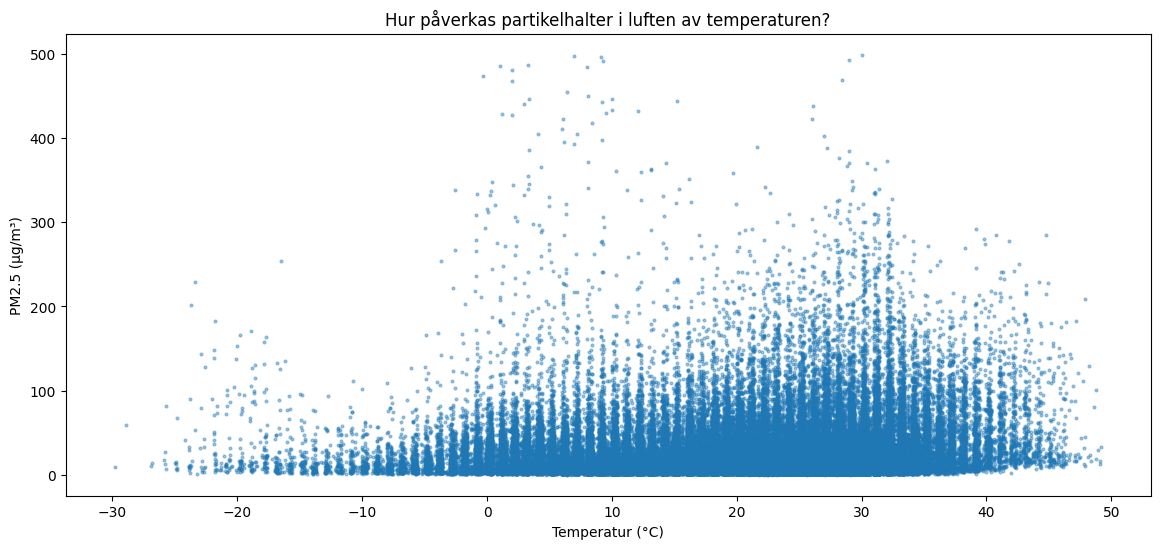

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Hur påverkas partikelhalter i luften av temperaturen?")
ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("PM2.5 (µg/m³)")

ax.scatter(
    df_clean["temperature_celsius"],
    df_clean["air_quality_PM2.5"],
    alpha=0.4,
    s=4
)

plt.show()

Scatter på hela datan blir otydlig. Datan klumpas ihop och gör mönster svåra att urskilja. Testar ett hexbin för att se vart större delen av datan befinner sig.

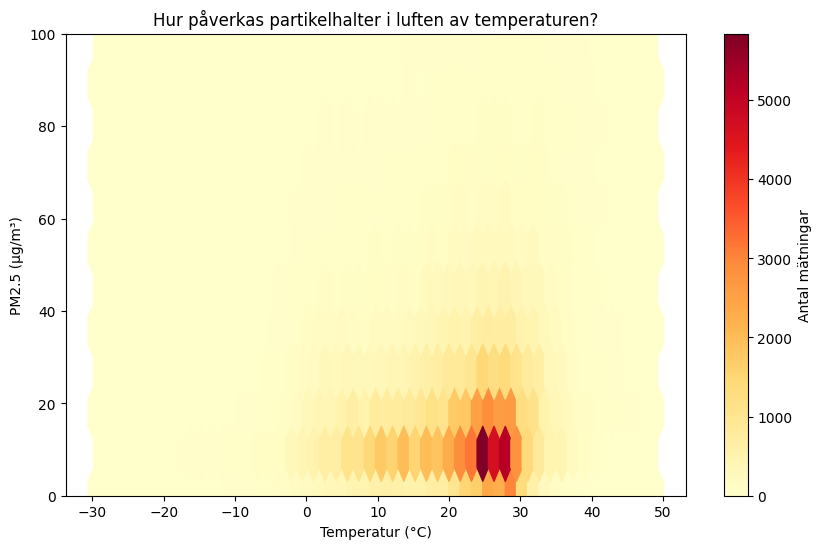

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Hur påverkas partikelhalter i luften av temperaturen?")
ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_ylim(0, 100)

ax.hexbin(
    df_clean["temperature_celsius"],
    df_clean["air_quality_PM2.5"],
    gridsize=50,
    cmap="YlOrRd"
)


plt.colorbar(ax.collections[0], ax=ax, label="Antal mätningar")
plt.show()

Hexbin visar att den mesta mätdatan finns vid 20 - 30 c. Y värdet sträcker sig till 500 men gjorde diagramet svårt att tyda. Kan skala ner Y värde utan väsentlig data förlust. De flesta mätningar ligger under gränsvärdet men det ligger ändå ganska många mätningar kring gränsvärdet på 35 μg/m3 eller över. Då skadlig är över 35 μg/m3 under 24h hade nogrannare mätningar (över dygnet) och visualisering kontenuerligt behövs för mer relevant visualisering. Fortsätter med ett linjediagram för tydligare visa trenden mellan PM2.5 och temp.

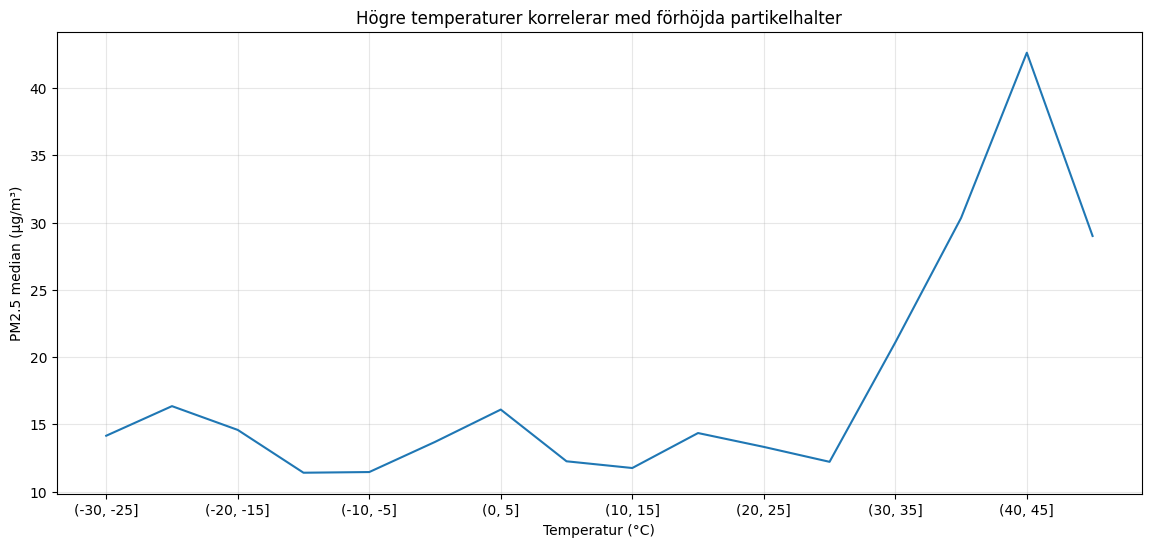

In [11]:
# Skapa intervaller för temperatur
df_clean["temp_bin"] = pd.cut(
    df_clean["temperature_celsius"],
    bins=[-30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    )

# Median för pm2.5 per intervall
median = df_clean.groupby("temp_bin")["air_quality_PM2.5"].median()

fig, ax = plt.subplots(figsize=(14, 6))


median.plot(ax=ax)

ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("PM2.5 median (µg/m³)")
ax.set_title("Högre temperaturer korrelerar med förhöjda partikelhalter")
ax.grid(alpha=0.3)

plt.show()

### Vilka länder har högst EPA median? 

Identifierar de länder som konsekvent har högst EPA median. Gick på en boxplot för att visa både median och spridning i datan. Visar vilka som har hög median och låg spridning (konunierligt dålig luft) medans vissa länder kan ha en hög spridning och hög median, då är luftkvaliteten inte lika dålig konstant.

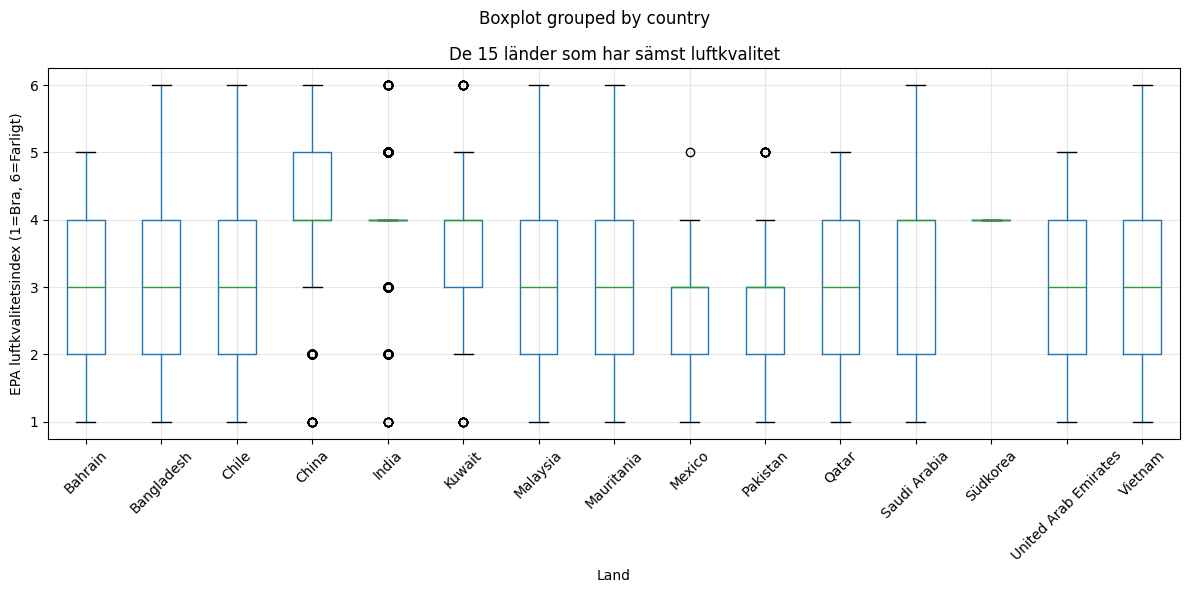

In [12]:
top_worst_countries = (
    df_clean.groupby("country")["air_quality_us-epa-index"]
    .median()
    .nlargest(15)
    .index
)

df_worst_countries = df_clean[df_clean["country"].isin(top_worst_countries)]

fig, ax = plt.subplots(figsize=(12, 6))

df_worst_countries.boxplot(
    column="air_quality_us-epa-index",
    by="country",
    ax=ax
)

ax.set_xlabel("Land")
ax.set_ylabel("EPA luftkvalitetsindex (1=Bra, 6=Farligt)")
ax.set_title("De 15 länder som har sämst luftkvalitet")

ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Här ser vi att kina är en utstickare med högst median och låg spridning. Indien och sydkorea har väldigt låg spridning med hg median vilken beskriver en väldigt dålig luftkvalitet. 

## Påverkas UV index av molnighet
### Gör ett scatter för att se påverkan av uv index vs molninghet

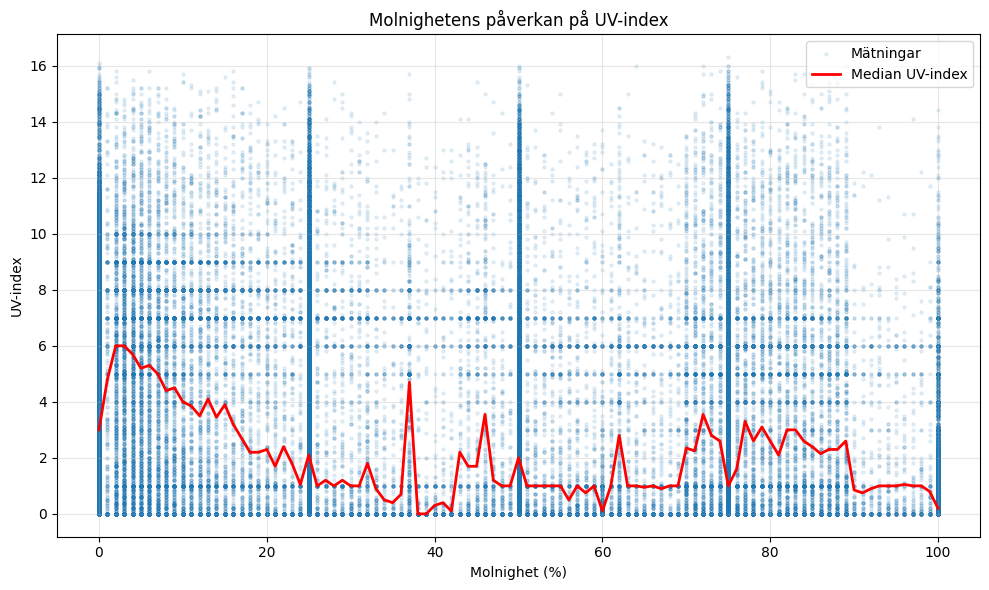

In [13]:
# Beräkna median UV per molntäckenivå
median_uv = df_clean.groupby("cloud")["uv_index"].median()

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter
ax.scatter(
    df_clean["cloud"],
    df_clean["uv_index"],
    alpha=0.1,
    s=5,
    label="Mätningar"
)

# Linjediagram ovanpå
ax.plot(
    median_uv.index,
    median_uv.values,
    color="red",
    linewidth=2,
    label="Median UV-index"
)

ax.set_xlabel("Molnighet (%)")
ax.set_ylabel("UV-index")
ax.set_title("Molnighetens påverkan på UV-index")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Valde att lägga till ett linjediagram i scatter. Den visar ändå en trend, något högre UV index vid mindre molnighet. Jag tror att denna påverkan borde vara rejält högre och jag tror svaret finns i datan. Hur mätningarna gjorts? När det gjorts? Ett specifikt set på en punkt med fler mätningar över dygnet hade nog gjort sig bättre för denna fråga. Testar en boxplot för att se också. 

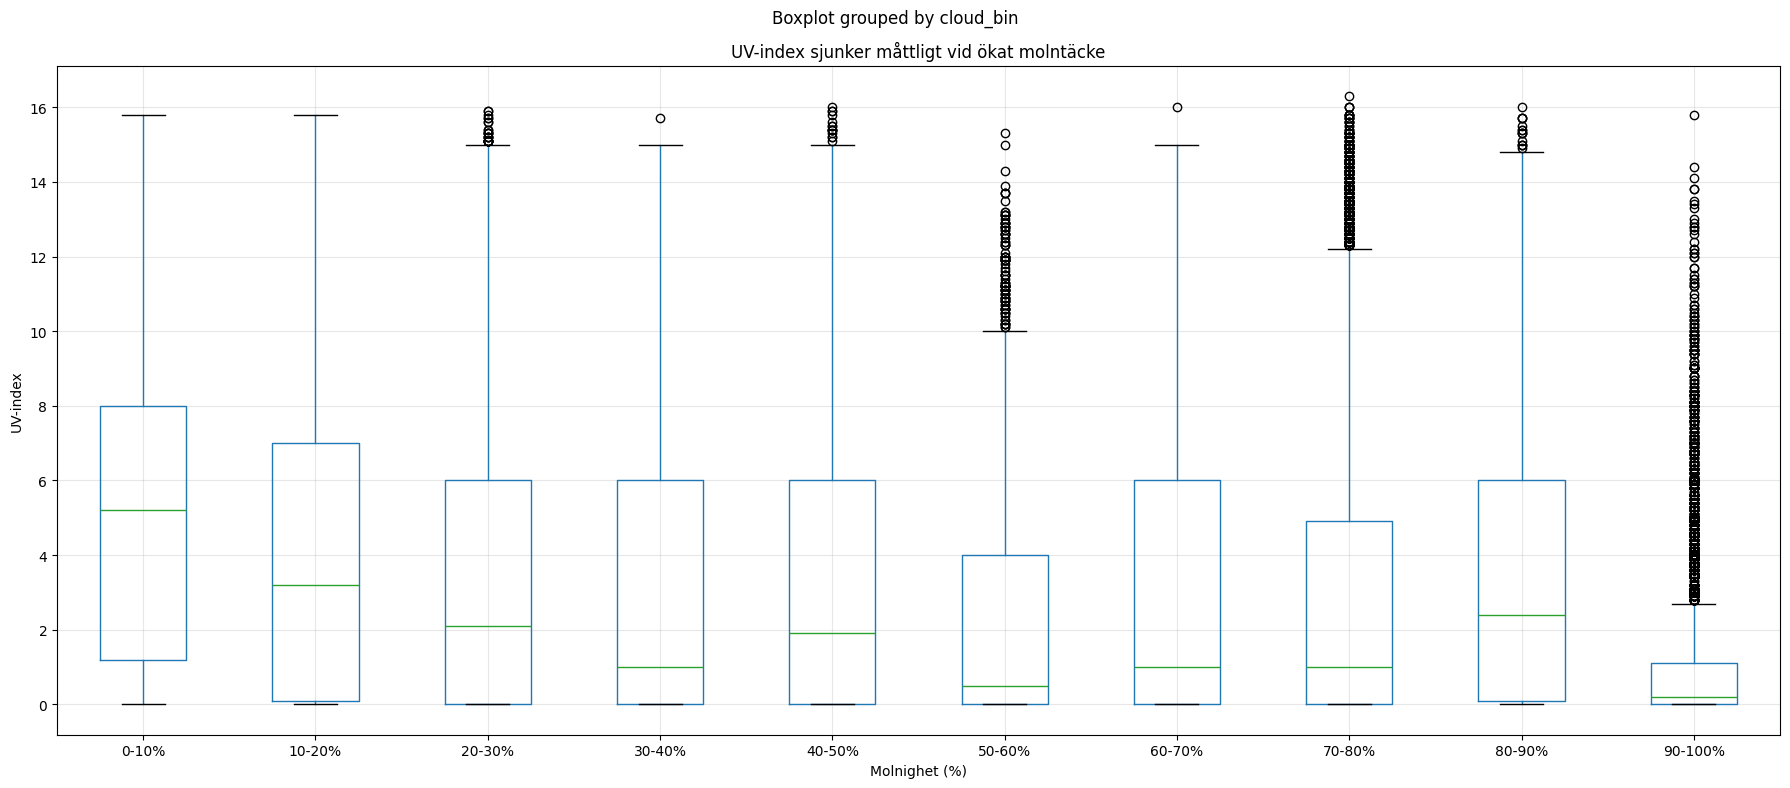

In [22]:
df_clean["cloud_bin"] = pd.cut(
    df_clean["cloud"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
)



fig, ax = plt.subplots(figsize=(18, 8))

df_clean.boxplot(
    column="uv_index",
    by="cloud_bin",
    ax=ax
)

ax.set_xlabel("Molnighet (%)")
ax.set_ylabel("UV-index")
ax.set_title("UV-index sjunker måttligt vid ökat molntäcke")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Boxplot behöver delas in i bins för att inte vara så stökig men jag fick slut på tid. 

Bin boxplot 
trendlinje 
Titlar som påstående
(Gör om en fråga till hypotes)

## Avslutning

### Vad analysen visade

**Temperatur och PM2.5:** Högre temperaturer samvarierar med förhöjda partikelhalter. 
Skulle tippa på ett geografiskt samband, varma städer i Asien och 
Mellanöstern har också mer industri, trafik och mindre klimatfokus generellt.

**EPA-index per land:** Kina, Indien och Sydkorea har konsekvent hög EPA-median med 
låg spridning vilket innebär att luftkvaliteten är dålig kontinuerligt, inte bara vid enstaka tillfällen.

**Molnighet och UV-index:** Sambandet finns men är svagare än förväntat. Jag tror datan har för låg mätningsfrekvens för att tyda molnighetens effekt. Jag tror även man hade behövt dyka mer in i datasetet för att se setets relevans för denna fråga

### Vad datan inte kan berätta

Datasetet skulle behöva fler mätningar per tidsintervall tror jag för att få bättre kvalitet. 
Mätningarna är dessutom ögonblicksvärden och inte medelvärden. Detta kan göra 
jämförelser mot WHO:s gränsvärden missvisande. Enskilda städer kan inte respresentera kvaliteten på luften i hela landet även om det är intressant att titta på ändå. 